# Build or load a World (`00-build-or-load-world`)

Generate a new **World** artifact with the LLM pipeline, or reload it silently on a warm
cache. Running against `data/worlds/fashion_retail_20/` requires **no API key**.

What this notebook covers:

1. `load_or_build_world` with a lazily-constructed `OpenAIClient` inside `build_fn`
2. Exploring the loaded World artifact (catalog, market, store templates)
3. Building a runnable graph `Scenario` from the World via `world_to_graph`
4. Running a short simulation and inspecting the run log

**No-key guarantee:** `OpenAIClient` and `WorldBuilder` are constructed **inside** `build_fn`,
so a warm cache (`world.json` already exists) never touches the OpenAI SDK.  
A cold cache without `OPENAI_API_KEY` raises `openai.AuthenticationError` with a clear message.

In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

# Navigate to repo root so src.* imports resolve.
while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import matplotlib
matplotlib.use('Agg')
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (9, 4)

## 1. Load or build the world

`load_or_build_world(name, build_fn)` checks `data/worlds/<name>/world.json`.  
On a **cache hit** it returns the saved `World` immediately — `build_fn` is never called, so no
`OpenAIClient` is ever constructed and no API key is needed.  
On a **cache miss** it calls `build_fn()`. If `OPENAI_API_KEY` is not set the OpenAI SDK
raises `openai.AuthenticationError` with a clear actionable message.

In [2]:
from src.llm.world_builder import load_or_build_world

# Configuration
ARCHETYPE = 'fashion_retail'
N_ITEMS = 20
WORLD_NAME = f'{ARCHETYPE}_{N_ITEMS}'   # -> data/worlds/fashion_retail_20/world.json


def build_fn():
    """
    Build a new World via the LLM pipeline.

    OpenAIClient and WorldBuilder are constructed LAZILY inside this closure:
    they are only instantiated when build_fn() is actually called (cache miss).
    A warm cache means build_fn is never called and no API key is needed.
    """
    from src.llm.openai_client import OpenAIClient
    from src.llm.world_builder import WorldBuilder
    client = OpenAIClient()                        # reads OPENAI_API_KEY here
    builder = WorldBuilder(archetype=ARCHETYPE, client=client, max_retries=5)
    return builder.build(n_items=N_ITEMS)


world = load_or_build_world(WORLD_NAME, build_fn, auto_confirm=True)
print(f'World loaded: {len(world.catalog)} catalog items')
print(f'Archetype: {world.meta["archetype"] if world.meta else "unknown"}')
print(f'Regions: {world.market.regions}')

World loaded: 20 catalog items
Archetype: fashion_retail
Regions: ['US']


## 2. Explore the World artifact

In [3]:
# Provenance: archetype, item count, model, builder version, built_at
world.meta_df()

,archetype,n_items,model,builder_version,built_at
0,fashion_retail,20,None,1,2026-06-03T13:23:26.783231+00:00


In [4]:
# Market parameters: cycle, seasonal factors, regions, shocks
world.market_df().T

,0
cycle_len,365
cycle_amp,0.001
init_demand,1.2
init_supply,1.2
peak_factor,1.3
off_factor,0.6
season_months,"{'spring/summer': [3, 4, 5, 6, 7, 8], 'fall/wi..."
regions,[US]
correlation,0.7
trend_update_interval,20


In [5]:
# Store templates (capacity, balance, delivery lag, …)
world.store_templates_df().set_index('id')

,region,capacity,init_balance,init_stock_pct,delivery_lag,holding_rate,order_fee,init_active_count,init_active_products,init_freshness
id,,,,,,,,,,
flagship_20,US,10000,1000000.0,0.0,1.0,0.01,10.0,10,None,baseline


In [6]:
# Catalog: one row per SKU
world.catalog_df()

,product_id,name,category,base_price,unit_cost,margin,seasonality,freshness_alpha,freshness_decay,init_stage,stage_change_probs,init_stock_share,related_products
0,P0000,Slim Fit Chinos,Trousers,75.0,30.0,45.0,all_season,None,None,None,None,None,[]
1,P0001,Floral Summer Dress,Dresses,90.0,36.0,54.0,spring_summer,None,None,None,None,None,[]
2,P0002,Wool Coat,Outerwear,250.0,100.0,150.0,fall_winter,None,None,None,None,None,[]
3,P0003,Linen Shirt,Tops,65.0,26.0,39.0,spring_summer,None,None,None,None,None,[]
4,P0004,Denim Jeans,Trousers,85.0,34.0,51.0,all_season,None,None,None,None,None,[]
5,P0005,Cashmere Sweater,Knitwear,180.0,72.0,108.0,fall_winter,None,None,None,None,None,[]
6,P0006,Silk Blouse,Tops,120.0,48.0,72.0,all_season,None,None,None,None,None,[]
7,P0007,Leather Jacket,Outerwear,400.0,160.0,240.0,fall_winter,None,None,None,None,None,[]
8,P0008,Ankle Boots,Footwear,150.0,60.0,90.0,fall_winter,None,None,None,None,None,[]
9,P0009,Canvas Sneakers,Footwear,80.0,32.0,48.0,spring_summer,None,None,None,None,None,[]


### Catalog breakdown by seasonality

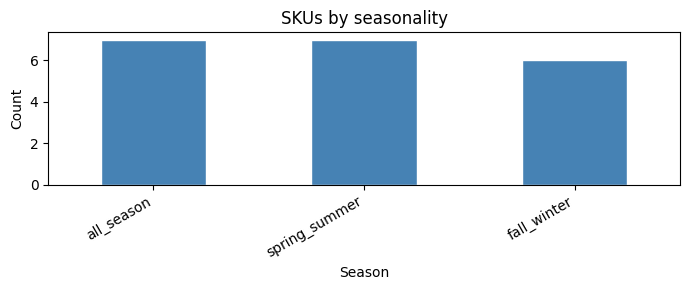

In [7]:
catalog_df = world.catalog_df()
season_counts = catalog_df['seasonality'].value_counts()

fig, ax = plt.subplots(figsize=(7, 3))
season_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('SKUs by seasonality')
ax.set_xlabel('Season')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. Synthesise a graph topology

`world_to_graph(world, sink_density=1.0)` turns each `StoreTemplate` into a
`factory -> shop -> sink-per-product` sub-graph.

In [8]:
from collections import Counter
from dataclasses import replace
from datetime import datetime

from src.sim.world import world_to_graph
from src.sim.scenario import DisruptionParams, ItemLifecycleParams, Scenario
from src.sim.distributions import Constant

# Rescale the template to a workable size for this demo
base_tmpl = next(iter(world.store_templates.values()))
demo_tmpl = replace(
    base_tmpl,
    id='flagship_20_demo',
    capacity=10000,
    init_balance=1_000_000.0,
    init_active_count=10,
    init_stock_pct=0.0,
    order_fee=10.0,
)
demo_world = replace(world, store_templates={'flagship_20_demo': demo_tmpl})

topology = world_to_graph(demo_world, sink_density=1.0)
nodes, edges = topology['node_instances'], topology['edges']

print(f'Nodes: {len(nodes)}  Edges: {len(edges)}')
print('Node types:', dict(Counter(type(ni.node).__name__ for ni in nodes)))

Nodes: 22  Edges: 21
Node types: {'FactoryNode': 1, 'IntermediateNode': 1, 'DemandSinkNode': 20}


## 4. Attach policies and build the Scenario

In [9]:
from src.sim.node import DemandSinkNode, FactoryNode, IntermediateNode
from src.sim.policy import DefaultDemandSinkPolicy, OrderUpToPolicy, StaticFactoryPolicy

LIFECYCLE_STAGES = ['introduction', 'growth', 'maturity', 'decline', 'dead']

for ni in nodes:
    if isinstance(ni.node, FactoryNode):
        ni.policy = StaticFactoryPolicy(
            capacity_per_tick=ni.node.capacity_per_tick,
            unit_cost=ni.node.unit_cost,
        )
    elif isinstance(ni.node, IntermediateNode):
        ni.policy = OrderUpToPolicy(policy_seed=42)
    elif isinstance(ni.node, DemandSinkNode):
        ni.policy = DefaultDemandSinkPolicy()

scenario = Scenario(
    catalog=demo_world.catalog,
    market=demo_world.market,
    disruption=DisruptionParams(
        event_prob=0.02,
        types=['natural_disaster', 'economic_crisis'],
        regions=demo_world.market.regions,
        severity=Constant(0.05),
        duration=Constant(3),
    ),
    item_lifecycle=ItemLifecycleParams(
        stages=LIFECYCLE_STAGES,
        init_stage='maturity',
        default_stage_change_probs={
            'introduction': 0.004, 'growth': 0.003, 'maturity': 0.0005,
            'decline': 0.005, 'dead': 0.0001,
        },
    ),
    stores=[],
    nodes=nodes,
    edges=edges,
    n_steps=50,
    start_date=datetime(2024, 1, 1),
    world_seed=42,
)
print(f'Scenario: {len(scenario.nodes)} nodes, {len(scenario.edges)} edges, {scenario.n_steps} steps')
print(f'is_graph: {scenario.is_graph}')

Scenario: 22 nodes, 21 edges, 50 steps
is_graph: True


## 5. Run a short simulation

In [10]:
from src.sim.runner import Runner

run_log = Runner(scenario).run()
print('Run log keys:', list(run_log.keys()))
print(f'ticks logged: {len(run_log["ticks"])}')

Run log keys: ['n_steps', 'ticks', 'global']
ticks logged: 50


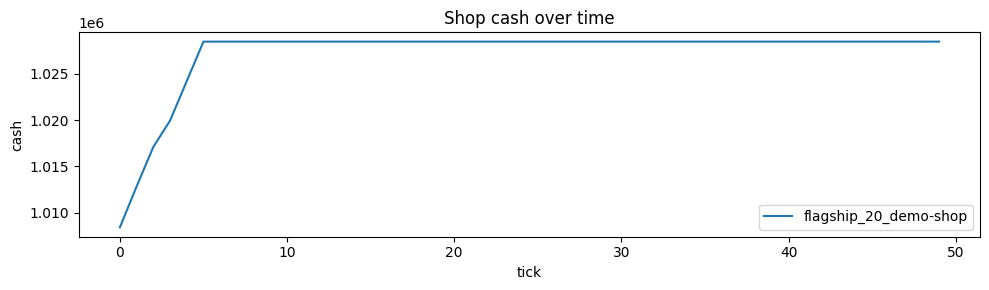

In [11]:
# Shop cash over time
shop_ids = [ni.node.id for ni in scenario.nodes if isinstance(ni.node, IntermediateNode)]

fig, ax = plt.subplots(figsize=(10, 3))
for sid in shop_ids:
    cash_series = [t['node_cash'].get(sid, 0.0) for t in run_log['ticks']]
    ax.plot(cash_series, label=sid)
ax.set_title('Shop cash over time')
ax.set_xlabel('tick')
ax.set_ylabel('cash')
ax.legend()
plt.tight_layout()
plt.show()

## Next steps

- **`notebooks/01-inspect-world.ipynb`** — walk every `World` inspection surface and derive a graph scenario.
- **`notebooks/02-inspect-scenario.ipynb`** — full scenario inspection with `nodes_df()` / `edges_df()`.
- **`notebooks/06-policy-comparison.ipynb`** — compare the four textbook reorder policies on this world.